# 04 — ML Model: Length-of-Stay Drivers

Train a patient-level LightGBM model to predict kidney stone length of stay (`DIAS_PERM`).
Use SHAP to identify which hospital-operational and patient features drive longer stays.

Tests hypothesis H3 from EXPERIMENT.md.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

from shared import OUTPUT_DIR, DATA_DIR, PLOT_DIR, METRICS_DIR

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = pd.read_parquet(DATA_DIR / "kidney_sih.parquet")
print(f"Loaded {len(kidney):,} records")

/Users/gsampaio/redhat/customers/prodesp/health-sus-agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 206,500 records


## Feature Engineering

Build patient-level and hospital-level features. Avoid data leakage:
- NO features derived from the target (DIAS_PERM)
- NO outcome features (MORTE, UTI) as predictors

In [2]:
NEW_PROC = "0409010596"
LITHO_PROC = "0409010146"

kidney["PROC_REA"] = kidney["PROC_REA"].astype(str).str.strip()

# SEXO and CAR_INT are stored as strings in the parquet
kidney["is_emergency"] = (kidney["CAR_INT"].astype(str) == "02").astype(int)
kidney["is_male"] = (kidney["SEXO"].astype(str) == "1").astype(int)
kidney["has_new_proc"] = (kidney["PROC_REA"] == NEW_PROC).astype(int)
kidney["has_litho"] = (kidney["PROC_REA"] == LITHO_PROC).astype(int)
kidney["age"] = pd.to_numeric(kidney["IDADE"], errors="coerce").fillna(0)

# Hospital-level aggregate features (computed per CNES from full dataset)
hospital_stats = kidney.groupby("CNES").agg(
    hospital_volume=("DIAG_PRINC", "count"),
    hospital_er_rate=("is_emergency", "mean"),
    hospital_new_proc_rate=("has_new_proc", "mean"),
    hospital_litho_rate=("has_litho", "mean"),
).reset_index()

# Conservative treatment = neither new proc nor lithotripsy
kidney["is_conservative"] = ((kidney["has_new_proc"] == 0) & (kidney["has_litho"] == 0)).astype(int)
conservative_by_hospital = kidney.groupby("CNES")["is_conservative"].mean().reset_index()
conservative_by_hospital.columns = ["CNES", "hospital_conservative_rate"]

hospital_stats = hospital_stats.merge(conservative_by_hospital, on="CNES", how="left")

kidney = kidney.merge(hospital_stats, on="CNES", how="left")

print(f"Unique hospitals: {kidney['CNES'].nunique()}")
print(f"Features added: hospital_volume, hospital_er_rate, hospital_new_proc_rate, hospital_litho_rate, hospital_conservative_rate")

Unique hospitals: 510
Features added: hospital_volume, hospital_er_rate, hospital_new_proc_rate, hospital_litho_rate, hospital_conservative_rate


## Train/Test Split (Temporal)

In [3]:
FEATURE_COLS = [
    # Patient features
    "is_emergency", "is_male", "has_new_proc", "has_litho", "age",
    # Hospital features
    "hospital_volume", "hospital_er_rate", "hospital_new_proc_rate",
    "hospital_litho_rate", "hospital_conservative_rate",
]

TARGET = "DIAS_PERM"

# Temporal split: train on 2014-2021, test on 2022-2024
valid = kidney[FEATURE_COLS + [TARGET, "year"]].dropna()
train = valid[valid["year"] <= 2021]
test = valid[valid["year"] >= 2022]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test = test[FEATURE_COLS]
y_test = test[TARGET]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Target mean — train: {y_train.mean():.2f} | test: {y_test.mean():.2f}")

Train: 97,803 | Test: 108,697
Target mean — train: 2.68 | test: 2.26


## Train LightGBM

In [4]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

y_pred = model.predict(X_test)
print(f"Best iteration: {model.best_iteration_}")

Best iteration: 217


## Evaluate

Model Performance:
  r2: 0.0961
  mae: 1.6005
  rmse: 2.924
  n_train: 97803
  n_test: 108697
  n_features: 10
  best_iteration: 217
  baseline_mae: 1.5592
  baseline_r2: -0.0072


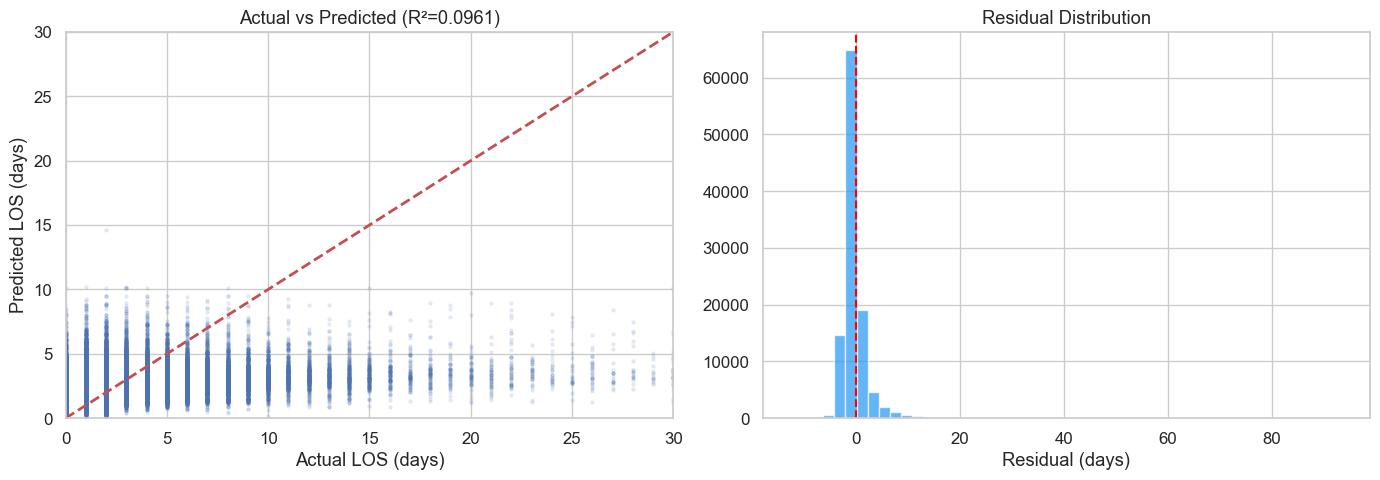

In [5]:
metrics = {
    "r2": round(r2_score(y_test, y_pred), 4),
    "mae": round(mean_absolute_error(y_test, y_pred), 4),
    "rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "n_features": len(FEATURE_COLS),
    "best_iteration": model.best_iteration_,
}

# Naive baseline: predict mean
naive_pred = np.full_like(y_test, y_train.mean())
metrics["baseline_mae"] = round(mean_absolute_error(y_test, naive_pred), 4)
metrics["baseline_r2"] = round(r2_score(y_test, naive_pred), 4)

print("Model Performance:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

with open(METRICS_DIR / "ml_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Actual vs predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.1, s=5)
axes[0].plot([0, 30], [0, 30], "r--", linewidth=2)
axes[0].set_title(f"Actual vs Predicted (R²={metrics['r2']})")
axes[0].set_xlabel("Actual LOS (days)")
axes[0].set_ylabel("Predicted LOS (days)")
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 30)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color="#2196F3", alpha=0.7)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (days)")
axes[1].axvline(0, color="red", linestyle="--")

plt.tight_layout()
plt.savefig(PLOT_DIR / "04_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP Analysis

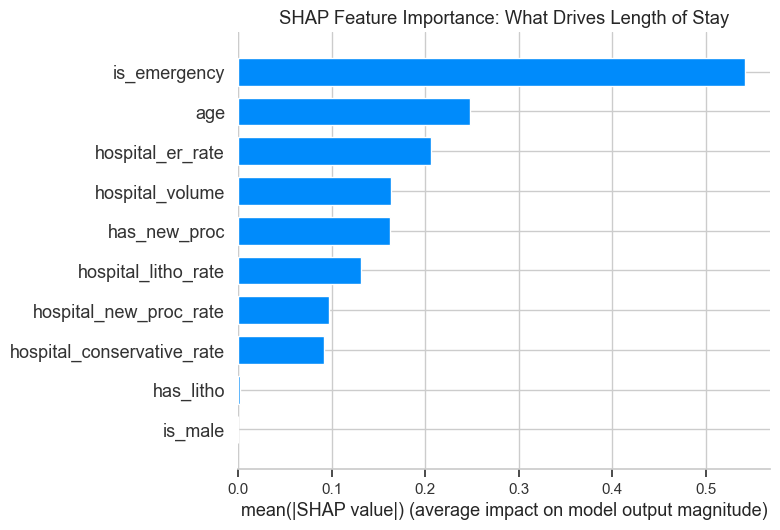

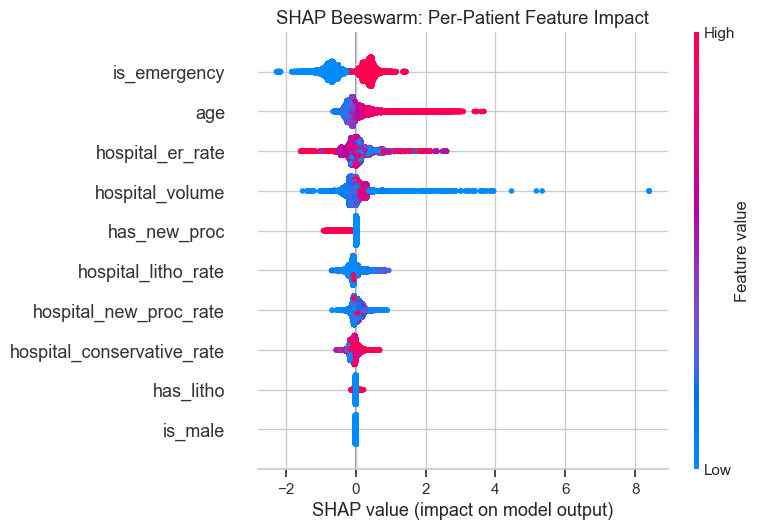

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Feature importance
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance: What Drives Length of Stay")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm: Per-Patient Feature Impact")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP Interaction Effects

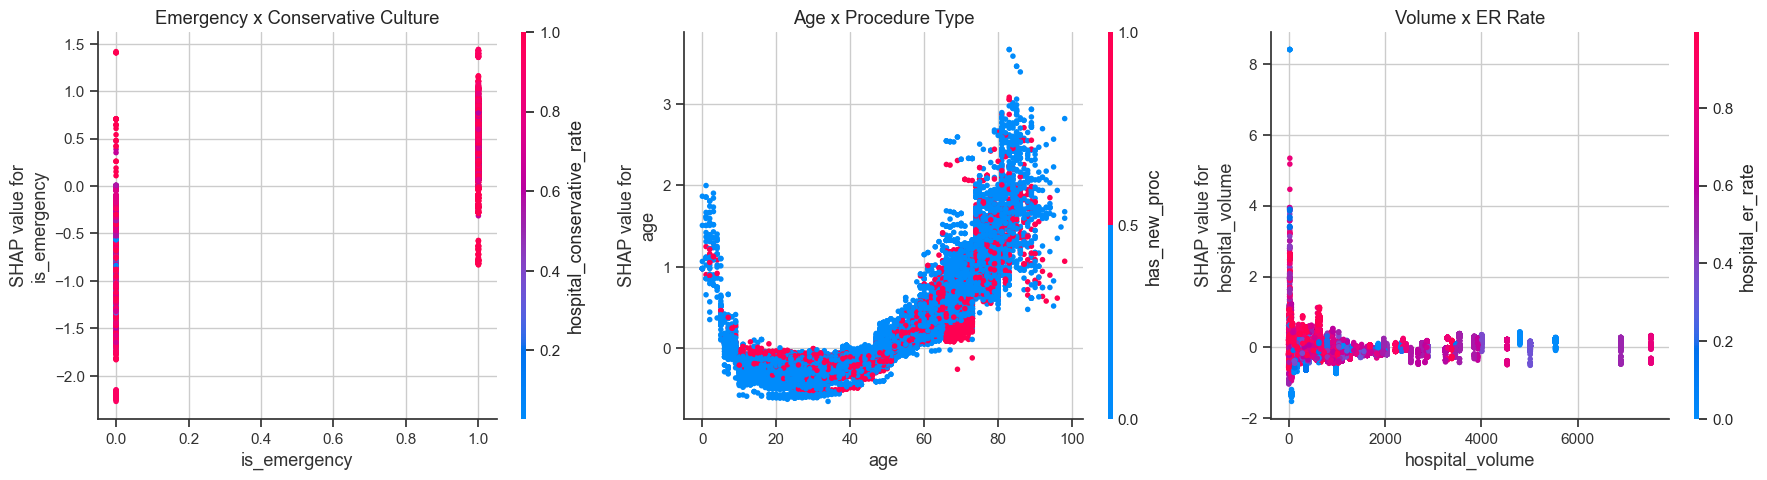

In [7]:
# Top interaction pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

shap.dependence_plot("is_emergency", shap_values, X_test,
                     interaction_index="hospital_conservative_rate",
                     ax=axes[0], show=False)
axes[0].set_title("Emergency x Conservative Culture")

shap.dependence_plot("age", shap_values, X_test,
                     interaction_index="has_new_proc",
                     ax=axes[1], show=False)
axes[1].set_title("Age x Procedure Type")

shap.dependence_plot("hospital_volume", shap_values, X_test,
                     interaction_index="hospital_er_rate",
                     ax=axes[2], show=False)
axes[2].set_title("Volume x ER Rate")

plt.tight_layout()
plt.savefig(PLOT_DIR / "04_shap_interactions.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Artifacts

In [8]:
np.save(OUTPUT_DIR / "shap_values.npy", shap_values)
np.save(OUTPUT_DIR / "X_test.npy", X_test.values)
np.save(OUTPUT_DIR / "y_test.npy", y_test.values)
np.save(OUTPUT_DIR / "y_pred.npy", y_pred)

with open(OUTPUT_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURE_COLS, f)

# Save the model
model.booster_.save_model(str(OUTPUT_DIR / "lgbm_model.txt"))

print("ML model complete. Artifacts saved to outputs/")
print(f"Key insight: Top SHAP feature is '{FEATURE_COLS[np.argmax(np.abs(shap_values).mean(0))]}'")

ML model complete. Artifacts saved to outputs/
Key insight: Top SHAP feature is 'is_emergency'
